# GTEx LORO Tensor Reconstructions — Single

Standalone single-tensor renders of the held-out `loro_truth` and its
reconstruction `loro_recon`, on the matched native-GTEx-parcel axis
(`region_matched`). Region ticks are dense (`REGION_TICK_STEP=1`) so every
parcel is labeled. Dense `loro_fused` / `fullfit` and all AHBA joint renders
live in `eval_gxp_samples_predictions_joint.ipynb`.

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.eval_utils.eval_style import set_academic_style
from src.eval_utils.eda_core import prepare_pre_post_harmonization_cached
from src.eval_utils.results_eda import EDAConfig

from src.eval_utils.eval_flattened import (
    build_donor_median_flattened_matrix,
    build_flattened_tensor_matrix,
    build_paired_flattened_tensor_matrices,
    gene_correlation_table,
    plot_flattened_tensor_matrices,
    sample_correlation_table,
)
from src.eval_utils.eval_samples import (
    MatchingContext,
    build_combat_tensor_view,
    build_prediction_tensor_view,
    plot_gtex_tensor_voxels,
)

set_academic_style()

In [16]:
SMALL = True

# Cache pointer must match cfg below: cache_root encodes the matching policy.
#   loro_subject_cache_cv → centroids_and_volumes
#   loro_subject_cache_c  → centroids
CACHE_ROOT = 'out/loro_subject_cache_cv'
MODEL_NAME = 'dlam'    # active model for standalone 3D tensor renders
GENE_SCOPE = 'allgenes'

CSV_PATH = 'data/raw/gxp_samples.csv'   # caches were built against the full CSV
ACTIVE_GENE_LIST = 'richiardi2015'        # post-cube gene-axis filter; None keeps all

MATCHING_POLICY = 'centroids_and_volumes'
MATCHING_POLICY_HEMI_MODE = 'force_left'
GTEX_REP_MODE = 'centroid'
GTEX_HEMI_MODE = 'mirror_left'
COLLAPSE_CEREBELLUM = False
MIN_OBSERVED_PARCELS = 5
COMBAT_USE_COVARIATES = True

# Region axis: matched native-GTEx parcels only (no AHBA-only superset block).
REGION_ORDERING = 'region_matched'

# Subsampling.
N_GTEX_SUBJECTS = 40 if SMALL else 200
N_AHBA_SUBJECTS = 6
N_GENES = 100 if SMALL else None
N_REGIONS = 80 if SMALL else None
RANDOM_SEED = 42

# Pre-filter subject list before loading (avoids stacking the full ~300 npz files).
import random as _random
_random.seed(RANDOM_SEED)
_all_subjects = sorted(p.stem for p in (Path(CACHE_ROOT) / GENE_SCOPE / MODEL_NAME).glob('*.npz'))
if SMALL and N_GTEX_SUBJECTS < len(_all_subjects):
    SUBJECTS_TO_LOAD = sorted(_random.sample(_all_subjects, N_GTEX_SUBJECTS))
else:
    SUBJECTS_TO_LOAD = None
print(f'npz subjects available: {len(_all_subjects)}; loading: '
      f'{len(SUBJECTS_TO_LOAD) if SUBJECTS_TO_LOAD else len(_all_subjects)}')

# Standalone single-tensor stages: held-out truth and its reconstruction.
STAGES = ('loro_truth', 'loro_recon')
STAGE_TITLES = {
    'loro_truth':  'LORO truth (held-out)',
    'loro_recon':  'LORO recon (held-out predictions)',
}

# Render knobs (same as combat notebook for A/B comparability)
MISSING_ALPHA = 1.0
# First pass: no translucency — extrapolated predictions render fully opaque.
# Titrate this < 1.0 later to encode prediction uncertainty.
FUTURE_IMPUTATION_ALPHA = 1.0
MASK_RENDER_MODE = 'two_pass'
FIGSIZE = 'auto'
AXES_BBOX = 'auto'
COLORBAR_BBOX = 'auto'
BOX_ASPECT = 'compressed_data'
BOX_ZOOM = 1
DPI = 300 if SMALL else 400
TITLE_PAD = 0.0
AXIS_ASSIGNMENT = ('gene', 'region', 'subject')
ELEV = 20.0
AZIM = 24.0
SUBJECT_TICK_STEP = 2
GENE_TICK_STEP = 10
REGION_TICK_STEP = 1
TICK_LABEL_PAD = -3.0
SUBJECT_LABEL_MODE = 'full'
GENE_LABEL_MODE = 'full'
SHOW_X_AXIS_LABEL = True
SHOW_Y_AXIS_LABEL = None
SHOW_Z_AXIS_LABEL = None
SHOW_AXIS_LABELS = False
SHOW_SUBJECT_TICKLABELS = True
SHOW_REGION_TICKLABELS = True
SHOW_REGION_LABEL_COLORS = False
SHOW_GENE_TICKLABELS = False
SHOW_AXIS_LINES = True
SHOW_TICK_LINES = True
SHOW_GRID = False
SHOW_LEGEND = True


npz subjects available: 318; loading: 40


## Load PREPOST + MatchingContext

`MatchingContext` supplies the parcel/gene axes that label the prediction cubes. No AHBA reference is needed for the single-tensor renders.

In [17]:
cfg = EDAConfig(
    csv_path=CSV_PATH,
    cache_root=CACHE_ROOT,
    gene_scope=GENE_SCOPE,
    min_observed_parcels=MIN_OBSERVED_PARCELS,
    combat_use_covariates=COMBAT_USE_COVARIATES,
    gtex_rep_mode=GTEX_REP_MODE,
    gtex_hemi_mode=GTEX_HEMI_MODE,
    matching_policy=MATCHING_POLICY,
    matching_policy_hemi_mode=MATCHING_POLICY_HEMI_MODE,
    collapse_cerebellum=COLLAPSE_CEREBELLUM,
)
prepost = prepare_pre_post_harmonization_cached(cfg)
ctx = MatchingContext.from_cfg(cfg, prepost)
print(f'target parcels: {len(ctx.regions_full)}, genes: {len(ctx.genes_full)}')
print(f'matching policy: {ctx.matching["policy"]!r} hemi={ctx.matching["hemi_mode"]!r}')

[prepost_cache] hit  notebooks/cache/prepost/0f8616c23cf88e0f.pkl  (8961.2 MB)
target parcels: 150, genes: 11704
matching policy: 'centroids_and_volumes' hemi='force_left'


## Build GTEx single-tensor prediction views

In [18]:
tier_b_kwargs = dict(
    cfg=cfg,
    matching_context=ctx,
    region_ordering=REGION_ORDERING,
    gene_panel=ACTIVE_GENE_LIST,
    n_regions=N_REGIONS,
    n_genes=N_GENES,
    random_seed=RANDOM_SEED,
)

# GTEx single-tensor views (matched axis), one per held-out stage.
gtex_views = {}
for stage in STAGES:
    gtex_views[stage] = build_prediction_tensor_view(
        CACHE_ROOT, MODEL_NAME,
        dataset='GTEx', stage=stage,
        subjects=SUBJECTS_TO_LOAD,
        n_subjects=N_GTEX_SUBJECTS,
        **tier_b_kwargs,
    )

for stage, v in gtex_views.items():
    n_obs = int(v.observed_mask.sum())
    print(f'{stage:12s}: values={v.values.shape}, axis_kind={v.region_axis_kind}, obs_cells={n_obs}')

loro_truth  : values=(40, 12, 97), axis_kind=ahba_parcel, obs_cells=358
loro_recon  : values=(40, 12, 97), axis_kind=ahba_parcel, obs_cells=358


## Standalone GTEx single-dataset renders

In [19]:
# Render helpers — one tensor per cell below (no plot loops).
_COMMON = dict(
    missing_rgba=(0.78, 0.78, 0.78, MISSING_ALPHA),
    future_imputation_rgba=(0.78, 0.78, 0.78, FUTURE_IMPUTATION_ALPHA),
    figsize=FIGSIZE, dpi=DPI, axes_bbox=AXES_BBOX, colorbar_bbox=COLORBAR_BBOX,
    box_aspect=BOX_ASPECT, box_zoom=BOX_ZOOM, title_pad=TITLE_PAD,
    axis_assignment=AXIS_ASSIGNMENT, elev=ELEV, azim=AZIM,
    subject_tick_step=SUBJECT_TICK_STEP, gene_tick_step=GENE_TICK_STEP,
    region_tick_step=REGION_TICK_STEP, tick_label_pad=TICK_LABEL_PAD,
    subject_label_mode=SUBJECT_LABEL_MODE, gene_label_mode=GENE_LABEL_MODE,
    show_x_axis_label=SHOW_X_AXIS_LABEL, show_y_axis_label=SHOW_Y_AXIS_LABEL,
    show_z_axis_label=SHOW_Z_AXIS_LABEL, show_axis_labels=SHOW_AXIS_LABELS,
    show_subject_ticklabels=SHOW_SUBJECT_TICKLABELS,
    show_region_ticklabels=SHOW_REGION_TICKLABELS,
    show_region_label_colors=SHOW_REGION_LABEL_COLORS,
    show_gene_ticklabels=SHOW_GENE_TICKLABELS,
    show_axis_lines=SHOW_AXIS_LINES, show_tick_lines=SHOW_TICK_LINES,
    show_grid=SHOW_GRID, mask_render_mode=MASK_RENDER_MODE,
)

def _breakdown(view):
    ns, nr, ng = view.values.shape
    return f'{ns} subjects x {nr} regions x {ng} genes'

def render_standalone(stage):
    fig, ax = plot_gtex_tensor_voxels(gtex_views[stage], show_legend=False, **_COMMON)
    ax.set_title(f'GTEx {STAGE_TITLES[stage]}  ({_breakdown(gtex_views[stage])})', pad=float(TITLE_PAD))
    plt.show()
    return ax

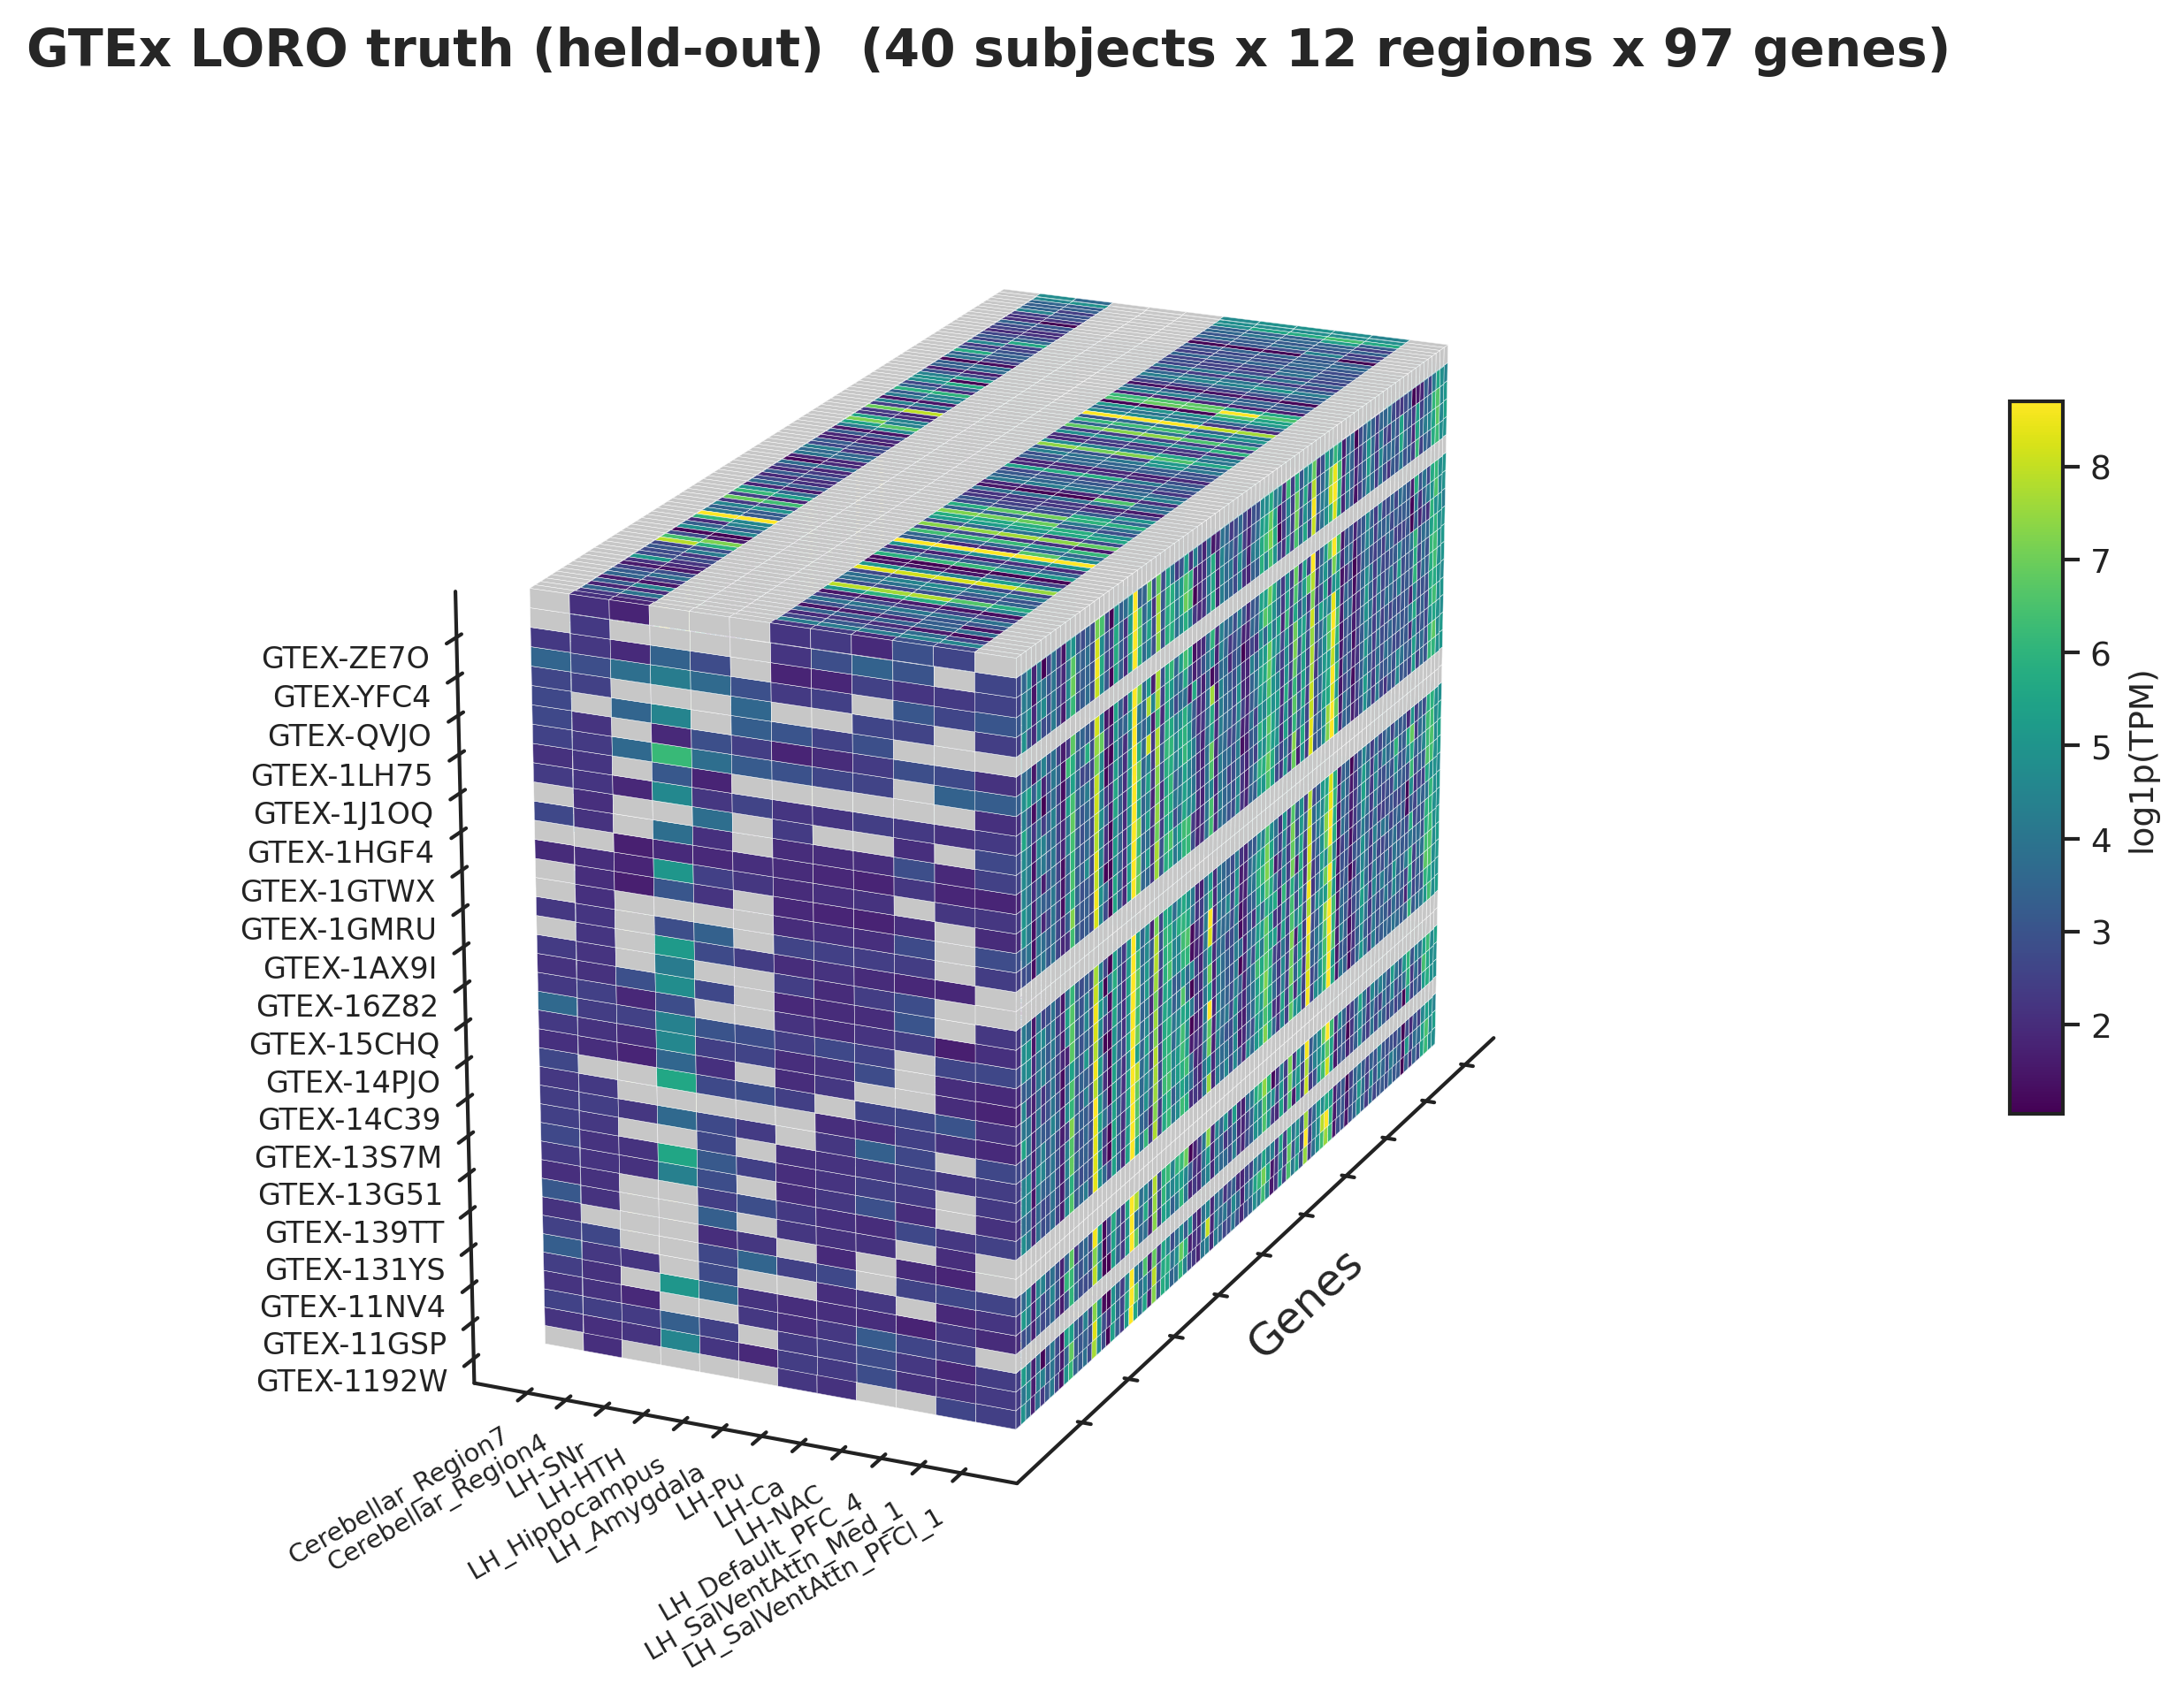

<Axes3D: title={'center': 'GTEx LORO truth (held-out)  (40 subjects x 12 regions x 97 genes)'}, xlabel='Genes'>

In [20]:
render_standalone('loro_truth')

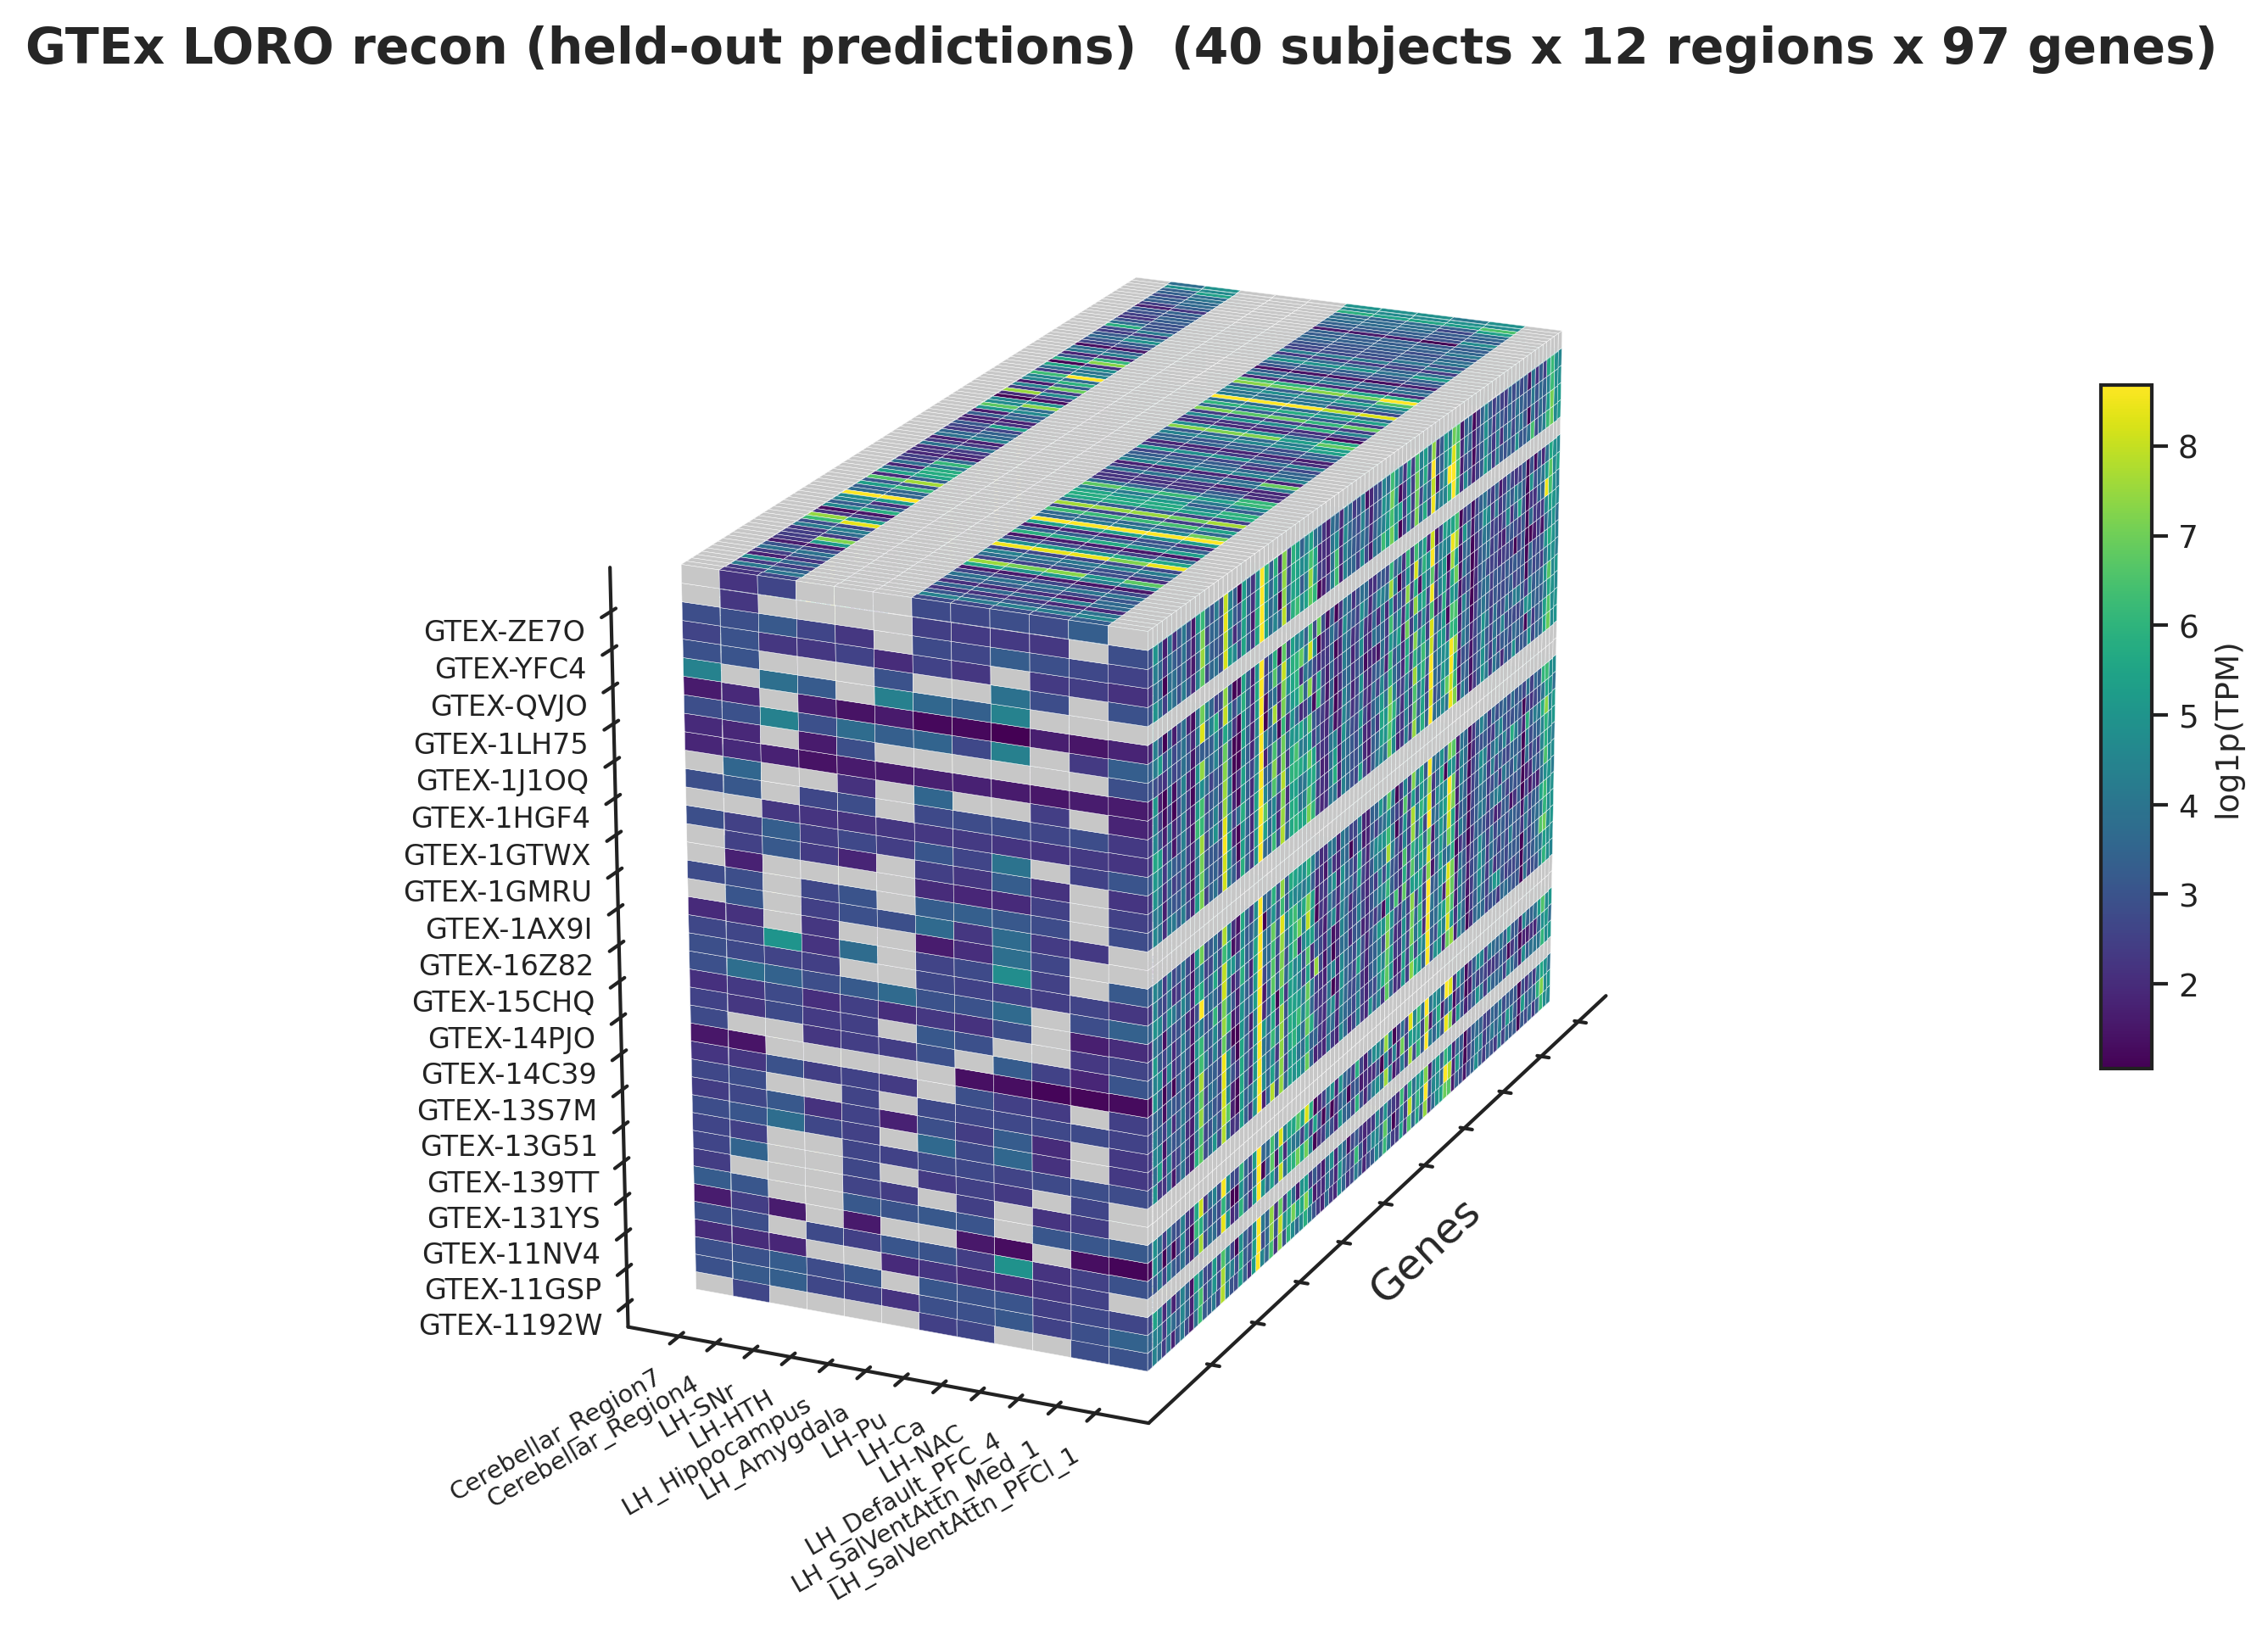

<Axes3D: title={'center': 'GTEx LORO recon (held-out predictions)  (40 subjects x 12 regions x 97 genes)'}, xlabel='Genes'>

In [21]:
render_standalone('loro_recon')

## Flattened truth/reconstruction matrices

Variantformer-style 2D matrices: rows are observed subject-region samples, columns are genes. Truth, naive, DLAM, and PLAM share row order and one color scale. The raw pre-ComBat GTEx panel is appended in the same figure as a standalone (its own subject rows and its own colorbar), since its scale and rows don't align with the harmonized panels.

**Self-contained:** this section builds its own prediction views from a dedicated `MAT_*` config (own subject/gene/region counts, gene panel, region axis); it does not reuse the 3D tensor views above.

In [22]:
# === Flattened matrix config — independent of the 3D tensor section above ===
# The matrix views are built fresh in the next cell; NOTHING is inherited from
# the tensor render section, so subject / gene / region counts, the gene panel,
# and the region axis can all differ freely from the standalone tensors.

# Reconstruction models compared as panels (truth + one panel per model).
MAT_MODEL_NAMES = ('naive', 'dlam', 'plam')

# Axis selection for the matrices.
MAT_REGION_ORDERING = 'region_matched'
MAT_GENE_PANEL = 'gtex_10deg' #'gtex_10deg' 'gtex_100hvg'  # small DEG panel; 'richiardi2015' / an explicit list / None also work

# Subsampling — independent of the tensor section (can be larger/smaller).
MAT_N_SUBJECTS = 4 if SMALL else 200
MAT_N_GENES = 10 if SMALL else None   # randomly sampled from MAT_GENE_PANEL (seeded by MAT_RANDOM_SEED)
MAT_N_REGIONS = 80 if SMALL else None
MAT_RANDOM_SEED = 42

# Own subject prefilter (enumerate from the first model's cache).
import random as _mat_random
_mat_random.seed(MAT_RANDOM_SEED)
_mat_all_subjects = sorted(p.stem for p in (Path(CACHE_ROOT) / GENE_SCOPE / MAT_MODEL_NAMES[0]).glob('*.npz'))
if SMALL and MAT_N_SUBJECTS < len(_mat_all_subjects):
    MAT_SUBJECTS_TO_LOAD = sorted(_mat_random.sample(_mat_all_subjects, MAT_N_SUBJECTS))
else:
    MAT_SUBJECTS_TO_LOAD = None
print(f'matrix npz subjects available: {len(_mat_all_subjects)}; loading: '
      f'{len(MAT_SUBJECTS_TO_LOAD) if MAT_SUBJECTS_TO_LOAD else len(_mat_all_subjects)}')

# Display toggles (decoupled from the tensor tick steps).
FLAT_GROUPBY = 'tissue'
FLAT_SUBJECT_LABEL_MODE = 'full'
FLAT_GENE_LABEL_MODE = 'full'
FLAT_GENE_TICK_STEP = 1
FLAT_SAMPLE_TICK_STEP = 1
FLAT_SHOW_GENE_TICKLABELS = False
FLAT_SHOW_SAMPLE_TICKLABELS = False
FLAT_SHOW_GROUP_LABELS = False
FLAT_SHOW_GROUP_SEPARATORS = True   # heavy lines between tissue groups
FLAT_SHOW_REGION_SEPARATORS = True   # lines between each region
FLAT_REGION_SEPARATOR_LINEWIDTH = 3   # thicker gray region delimiters
FLAT_REGION_SEPARATOR_COLOR = '#000000'
FLAT_REGION_SEPARATOR_ALPHA = 1.0
FLAT_SHOW_YLABEL = False             # y-axis title off by default
FLAT_GROUP_LABEL_X = -0.10
FLAT_GROUP_LABEL_FONTSIZE = 8
FLAT_CMAP = 'viridis'
FLAT_SOFTEN = True                   # soften viridis contrast (gentler on the eye)
FLAT_SOFTEN_AMOUNT = 0.35            # 0 = full contrast, 1 = flat grey
FLAT_SHARED_COLOR_SCALE = True
FLAT_VMIN = None
FLAT_VMAX = None
FLAT_FIGSIZE = (20, 10)   # somewhat longer (taller) panels
FLAT_NCOLS = 5                       # truth + 3 models + raw (standalone, own cbar)
FLAT_DPI = 400                       # high-resolution output for figures
FLAT_FONT_SCALE = 2.0                # scale all matrix fonts up relative to the plot
FLAT_CBAR_FONT_SCALE = 2.0           # extra multiplier on colorbar label + ticks (much larger)
FLAT_BORDER_LINEWIDTH = 2.0          # thickness of black border box around each matrix

matrix npz subjects available: 318; loading: 4


In [23]:
# Build the matrix views fresh — independent of the 3D tensor section.
mat_tier_b_kwargs = dict(
    cfg=cfg,
    matching_context=ctx,
    region_ordering=MAT_REGION_ORDERING,
    gene_panel=MAT_GENE_PANEL,
    n_regions=MAT_N_REGIONS,
    n_genes=MAT_N_GENES,
    random_seed=MAT_RANDOM_SEED,
)

# Held-out truth (model-invariant; enumerate from the first model's cache) and
# one loro_recon panel per model — all on the same MAT_* subject/axis sampling.
flat_truth_view = build_prediction_tensor_view(
    CACHE_ROOT, MAT_MODEL_NAMES[0],
    dataset='GTEx', stage='loro_truth',
    subjects=MAT_SUBJECTS_TO_LOAD,
    n_subjects=MAT_N_SUBJECTS,
    **mat_tier_b_kwargs,
)

flat_recon_views = {}
for model_name in MAT_MODEL_NAMES:
    flat_recon_views[model_name] = build_prediction_tensor_view(
        CACHE_ROOT, model_name,
        dataset='GTEx', stage='loro_recon',
        subjects=MAT_SUBJECTS_TO_LOAD,
        n_subjects=MAT_N_SUBJECTS,
        **mat_tier_b_kwargs,
    )

flat_matrices = []
flat_recon_matrices = {}
for model_name in MAT_MODEL_NAMES:
    truth_flat, recon_flat = build_paired_flattened_tensor_matrices(
        flat_truth_view,
        flat_recon_views[model_name],
        groupby=FLAT_GROUPBY,
        subject_label_mode=FLAT_SUBJECT_LABEL_MODE,
        truth_title='Truth',
        recon_title=model_name.upper(),
        value_label='Harmonized expression',
    )
    if not flat_matrices:
        flat_truth = truth_flat
        flat_matrices.append(flat_truth)
    flat_recon_matrices[model_name] = recon_flat
    flat_matrices.append(recon_flat)

print(f'flattened matrix: rows={flat_truth.X.shape[0]}, genes={flat_truth.X.shape[1]}')
display(flat_truth.row_metadata.groupby('group_label', sort=False).size().rename('rows').to_frame())

# Raw pre-ComBat GTEx as a standalone matrix (its own subject subsample from
# PREPOST; observed rows don't align with the LORO panels, so it isn't joined
# into the shared panel above).
#
# Pin the gene axis to the truth view's *already-selected* genes (in order) and
# disable resampling: the n_genes random pick in build_tensor_view_from_cube
# shares one rng with the subject pick, and raw samples subjects from the full
# PREPOST set (truth does not), so an independent n_genes draw would land on a
# different gene subset/order. Passing the explicit list guarantees alignment.
raw_kwargs = {**mat_tier_b_kwargs, 'gene_panel': list(flat_truth_view.genes), 'n_genes': None}
raw_gtex_view = build_combat_tensor_view(
    prepost, dataset='GTEx', stage='raw_matched',
    n_subjects=MAT_N_SUBJECTS, **raw_kwargs,
)
assert list(raw_gtex_view.genes) == list(flat_truth_view.genes), 'raw gene axis must match truth'
raw_gtex_flat = build_flattened_tensor_matrix(
    raw_gtex_view,
    groupby=FLAT_GROUPBY,
    subject_label_mode=FLAT_SUBJECT_LABEL_MODE,
    title='GTEx raw (pre-ComBat)',
    value_label='Raw expression',
)
print(f'raw GTEx matrix: rows={raw_gtex_flat.X.shape[0]}, genes={raw_gtex_flat.X.shape[1]}')


flattened matrix: rows=41, genes=10


,rows
group_label,
Frontal cortex (BA9),3
Anterior cingulate cortex (BA24),2
Cortex (BA10),4
Nucleus accumbens (basal ganglia),4
Caudate (basal ganglia),4
Putamen (basal ganglia),4
Amygdala,2
Hippocampus,4
Hypothalamus,4


raw GTEx matrix: rows=35, genes=10


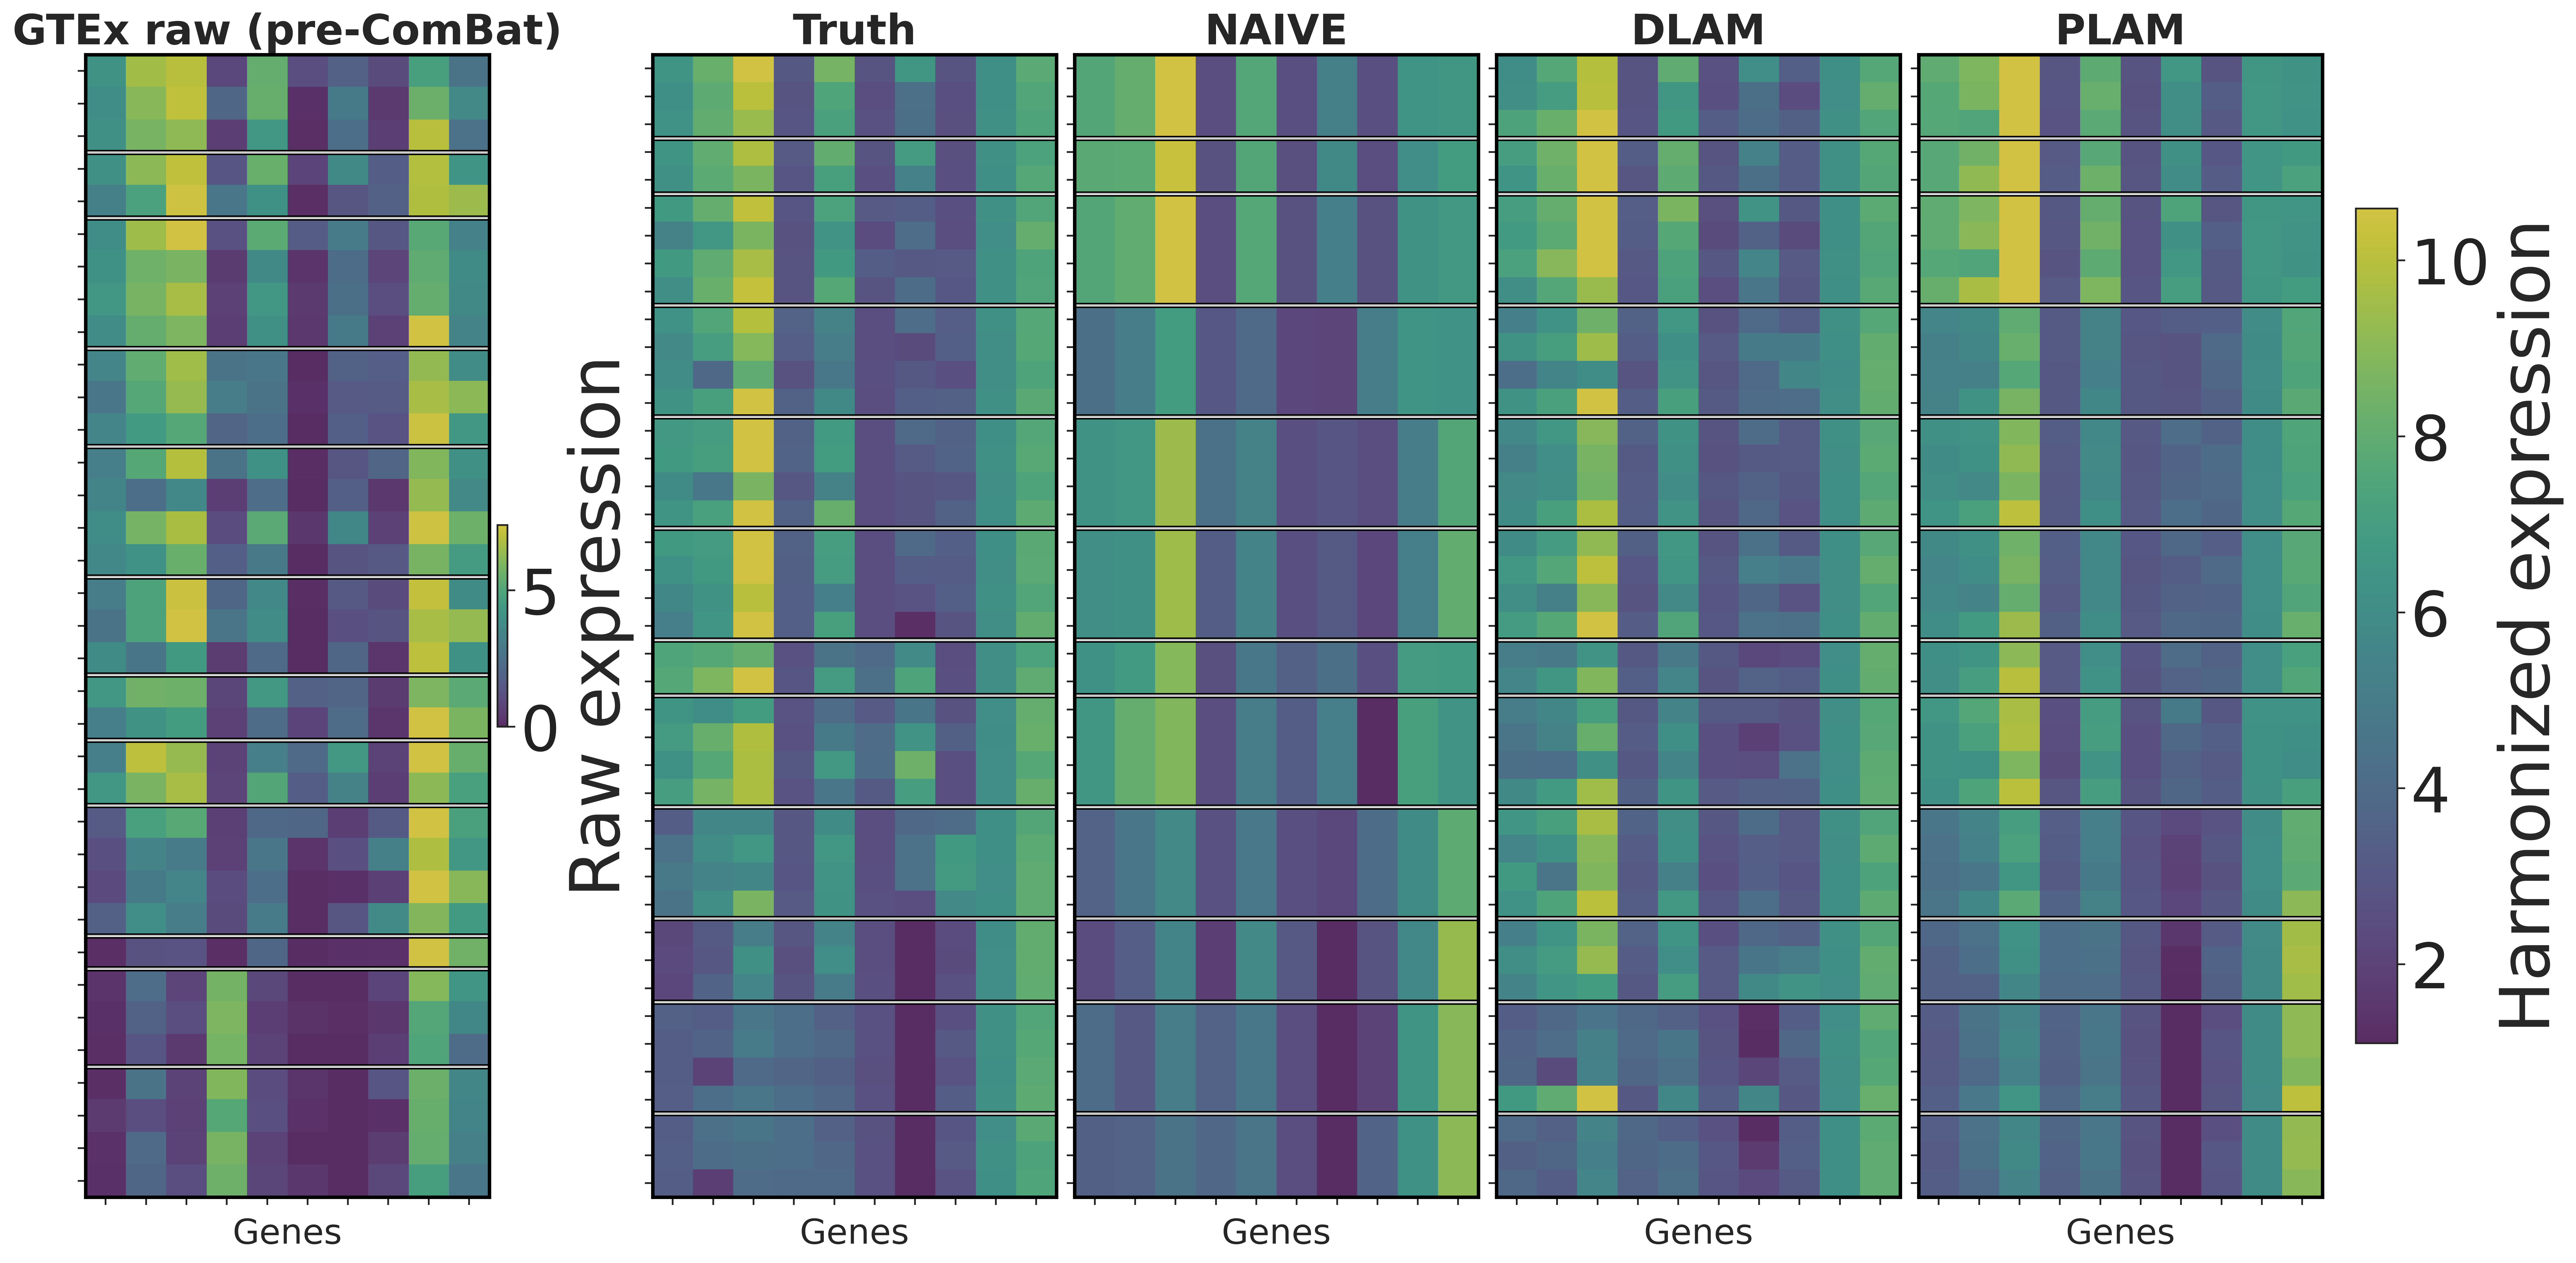

In [24]:
fig, axes = plot_flattened_tensor_matrices(
    flat_matrices,
    standalone_matrices=[raw_gtex_flat],
    standalone_first=True,
    ncols=FLAT_NCOLS,
    figsize=FLAT_FIGSIZE,
    cmap=FLAT_CMAP,
    shared_color_scale=FLAT_SHARED_COLOR_SCALE,
    vmin=FLAT_VMIN,
    vmax=FLAT_VMAX,
    suptitle=None,
    gene_tick_step=FLAT_GENE_TICK_STEP,
    sample_tick_step=FLAT_SAMPLE_TICK_STEP,
    gene_label_mode=FLAT_GENE_LABEL_MODE,
    show_gene_ticklabels=FLAT_SHOW_GENE_TICKLABELS,
    show_sample_ticklabels=FLAT_SHOW_SAMPLE_TICKLABELS,
    show_group_labels=FLAT_SHOW_GROUP_LABELS,
    show_group_separators=FLAT_SHOW_GROUP_SEPARATORS,
    show_region_separators=FLAT_SHOW_REGION_SEPARATORS,
    region_separator_linewidth=FLAT_REGION_SEPARATOR_LINEWIDTH,
    region_separator_color=FLAT_REGION_SEPARATOR_COLOR,
    region_separator_alpha=FLAT_REGION_SEPARATOR_ALPHA,
    soften=FLAT_SOFTEN,
    soften_amount=FLAT_SOFTEN_AMOUNT,
    show_ylabel=FLAT_SHOW_YLABEL,
    group_label_x=FLAT_GROUP_LABEL_X,
    group_label_fontsize=FLAT_GROUP_LABEL_FONTSIZE,
    font_scale=FLAT_FONT_SCALE,
    cbar_font_scale=FLAT_CBAR_FONT_SCALE,
    border_linewidth=FLAT_BORDER_LINEWIDTH,
    dpi=FLAT_DPI,
)
plt.show()


In [25]:
# Variantformer-style summaries: gene-wise correlations across rows and sample-wise correlations across genes.
gene_corr_tables = []
sample_corr_tables = []
for model_name, recon_flat in flat_recon_matrices.items():
    g = gene_correlation_table(flat_truth, recon_flat)
    g.insert(0, 'model', model_name)
    gene_corr_tables.append(g)
    s = sample_correlation_table(flat_truth, recon_flat)
    s.insert(0, 'model', model_name)
    sample_corr_tables.append(s)

gene_corr = pd.concat(gene_corr_tables, ignore_index=True)
sample_corr = pd.concat(sample_corr_tables, ignore_index=True)

display(gene_corr.groupby('model')['pearson_r'].describe())
display(sample_corr.groupby(['model', 'group_label'])['pearson_r'].describe())


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
dlam,10.0,0.302741,0.326109,-0.186181,0.076086,0.268143,0.594376,0.759552
naive,10.0,0.578958,0.345664,-0.131809,0.447916,0.738246,0.815255,0.861096
plam,10.0,0.349626,0.454569,-0.504586,0.070505,0.495325,0.705358,0.826821


count      mean       std       min  \
model group_label                                                              
dlam  Amygdala                             2.0  0.768357  0.086528  0.707173   
      Anterior cingulate cortex (BA24)     2.0  0.960263  0.002392  0.958571   
      Caudate (basal ganglia)              4.0  0.969614  0.007260  0.963036   
      Cerebellar hemisphere                4.0  0.835019  0.284673  0.408154   
      Cerebellum                           3.0  0.956266  0.017965  0.935988   
      Cortex (BA10)                        4.0  0.955826  0.023996  0.931701   
      Frontal cortex (BA9)                 3.0  0.984869  0.009681  0.975101   
      Hippocampus                          4.0  0.710624  0.203934  0.426676   
      Hypothalamus                         4.0  0.690685  0.129277  0.522621   
      Nucleus accumbens (basal ganglia)    4.0  0.886591  0.136293  0.684367   
      Putamen (basal ganglia)              4.0  0.956158  0.012314  0.946037   
      Substantia nigra                     3.0  0.663005  0.074521  0.579537   
naive Amygdala                             2.0  0.911993  0.022500  0.896083   
      Anterior cingulate cortex (BA24)     2.0  0.967116  0.006475  0.962537   
      Caudate (basal ganglia)              4.0  0.943626  0.017440  0.922755   
      Cerebellar hemisphere                4.0  0.963694  0.006946  0.954497   
      Cerebellum                           3.0  0.963602  0.009051  0.954489   
      Cortex (BA10)                        4.0  0.948899  0.020835  0.920824   
      Frontal cortex (BA9)                 3.0  0.968323  0.003846  0.964079   
      Hippocampus                          4.0  0.894126  0.030755  0.860868   
      Hypothalamus                         4.0  0.875960  0.047975  0.823297   
      Nucleus accumbens (basal ganglia)    4.0  0.819265  0.037717  0.789732   
      Putamen (basal ganglia)              4.0  0.960001  0.016550  0.935250   
      Substantia nigra                     3.0  0.966994  0.001243  0.965678   
plam  Amygdala                             2.0  0.845952  0.005428  0.842114   
      Anterior cingulate cortex (BA24)     2.0  0.955224  0.018970  0.941810   
      Caudate (basal ganglia)              4.0  0.976397  0.010353  0.961034   
      Cerebellar hemisphere                4.0  0.947426  0.012309  0.937428   
      Cerebellum                           3.0  0.939153  0.021067  0.917694   
      Cortex (BA10)                        4.0  0.890612  0.032327  0.869871   
      Frontal cortex (BA9)                 3.0  0.948809  0.014787  0.932587   
      Hippocampus                          4.0  0.805801  0.034410  0.769749   
      Hypothalamus                         4.0  0.772205  0.115275  0.639404   
      Nucleus accumbens (basal ganglia)    4.0  0.963240  0.011671  0.951983   
      Putamen (basal ganglia)              4.0  0.959562  0.010089  0.945126   
      Substantia nigra                     3.0  0.927263  0.020754  0.904431   

                                              25%       50%       75%  \
model group_label                                                       
dlam  Amygdala                           0.737765  0.768357  0.798949   
      Anterior cingulate cortex (BA24)   0.959417  0.960263  0.961108   
      Caudate (basal ganglia)            0.963482  0.969623  0.975756   
      Cerebellar hemisphere              0.827505  0.973507  0.981021   
      Cerebellum                         0.949302  0.962616  0.966405   
      Cortex (BA10)                      0.945858  0.951281  0.961249   
      Frontal cortex (BA9)               0.980074  0.985046  0.989753   
      Hippocampus                        0.640401  0.759184  0.829407   
      Hypothalamus                       0.655794  0.701108  0.735999   
      Nucleus accumbens (basal ganglia)  0.874654  0.939887  0.951825   
      Putamen (basal ganglia)            0.947970  0.952625  0.960813   
      Substantia nigra                   0.633080  

## AHBA vs GTEx subject-wise comparison

Stacked GTEx **subject-wise** matrix (rows = subject-region samples, sorted by subject, region_matched order within each subject) next to a single AHBA **donor-median** matrix (region_matched_superset order, median across donors per region/gene). Both share the same gene axis as the matrix section above, so columns are directly comparable.

In [29]:
# === AHBA vs GTEx subject-wise — self-contained config (own plotting toggles) ===
# Independent of the FLAT_* matrix section: own gene panel/count, subjects, and
# every display knob. Gridlines (region/group separators) are OFF by default.

# Data / axes.
CMP_GTEX_STAGE = 'harmonized'          # GTEx subject-wise stage: 'harmonized' | 'raw_matched'
CMP_N_SUBJECTS = 8 if SMALL else 200   # GTEx subjects stacked in the subject-wise view
CMP_GENE_PANEL = 'richiardi2015'         # panel with >=100 genes (gtex_10deg only has 10)
CMP_N_GENES = 100                      # gene count for this section
CMP_RANDOM_SEED = 42
CMP_GROUPBY_GTEX = 'subject'           # stack rows by subject
CMP_GROUPBY_AHBA = 'tissue'            # label AHBA median rows by native tissue

# Display toggles (own).
CMP_SUBJECT_LABEL_MODE = 'full'
CMP_GENE_LABEL_MODE = 'full'
CMP_GENE_TICK_STEP = 10
CMP_SAMPLE_TICK_STEP = 1
CMP_SHOW_GENE_TICKLABELS = False
CMP_SHOW_SAMPLE_TICKLABELS = False
CMP_SHOW_GROUP_LABELS = True
CMP_SHOW_GROUP_SEPARATORS = False      # gridlines off by default
CMP_SHOW_REGION_SEPARATORS = False     # gridlines off by default
CMP_REGION_SEPARATOR_LINEWIDTH = 1.4
CMP_REGION_SEPARATOR_COLOR = '#808080'
CMP_REGION_SEPARATOR_ALPHA = 0.7
CMP_SHOW_YLABEL = False
CMP_GROUP_LABEL_X = -0.10
CMP_GROUP_LABEL_FONTSIZE = 8
CMP_CMAP = 'viridis'
CMP_SOFTEN = True
CMP_SOFTEN_AMOUNT = 0.35
CMP_SHARED_COLOR_SCALE = True
CMP_FIGSIZE = (20, 7)
CMP_NCOLS = 2
CMP_DPI = 300
CMP_FONT_SCALE = 2.0
CMP_CBAR_FONT_SCALE = 2.0
CMP_BORDER_LINEWIDTH = 2.0

In [30]:
# GTEx subject-wise: rows = (subject, region), grouped/sorted by subject,
# canonical region_matched order within each subject. Own gene selection.
gtex_subjwise_view = build_combat_tensor_view(
    prepost, dataset='GTEx', stage=CMP_GTEX_STAGE,
    cfg=cfg, matching_context=ctx,
    region_ordering='region_matched',
    gene_panel=CMP_GENE_PANEL, n_genes=CMP_N_GENES,
    n_subjects=CMP_N_SUBJECTS, random_seed=CMP_RANDOM_SEED,
)
gtex_subjwise_flat = build_flattened_tensor_matrix(
    gtex_subjwise_view,
    groupby=CMP_GROUPBY_GTEX,
    subject_label_mode=CMP_SUBJECT_LABEL_MODE,
    title=f'GTEx subject-wise ({CMP_GTEX_STAGE})',
    value_label='Expression',
)

# AHBA donor median: rows = regions in region_matched_superset order, median
# across donors per region/gene; gene axis pinned to the GTEx view so columns match.
ahba_super_view = build_combat_tensor_view(
    prepost, dataset='AHBA', stage='harmonized',
    cfg=cfg, matching_context=ctx,
    region_ordering='region_matched_superset',
    gene_panel=list(gtex_subjwise_view.genes), n_genes=None,
    random_seed=CMP_RANDOM_SEED,
)
ahba_median_flat = build_donor_median_flattened_matrix(
    ahba_super_view,
    groupby=CMP_GROUPBY_AHBA,
    title='AHBA donor median (superset)',
    value_label='Median expression',
)
assert list(gtex_subjwise_flat.genes) == list(ahba_median_flat.genes), 'gene axes must match'
print(f'GTEx subject-wise: rows={gtex_subjwise_flat.X.shape[0]}, genes={gtex_subjwise_flat.X.shape[1]}')
print(f'AHBA donor median: regions={ahba_median_flat.X.shape[0]}, genes={ahba_median_flat.X.shape[1]}')

GTEx subject-wise: rows=69, genes=97
AHBA donor median: regions=150, genes=97


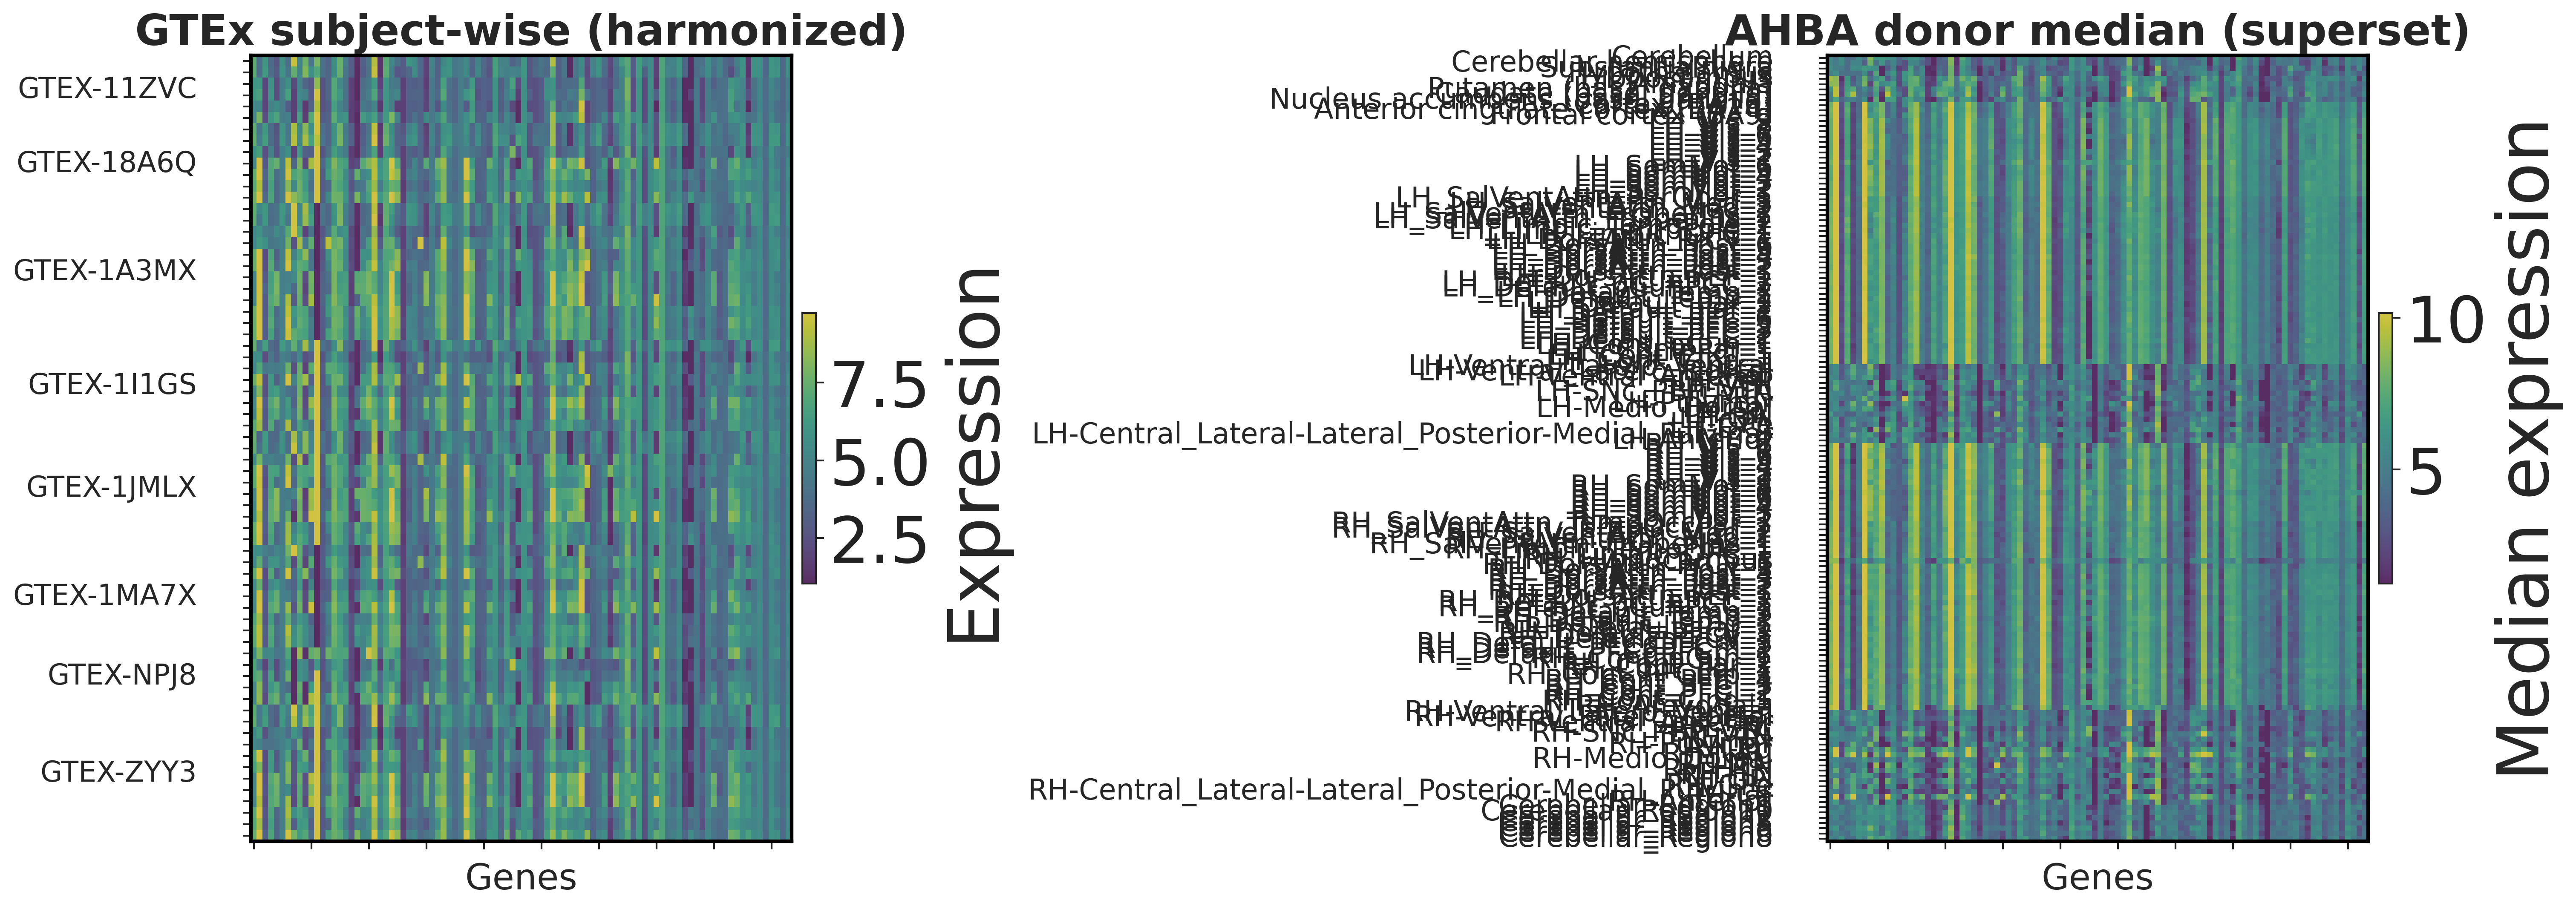

In [28]:
fig, axes = plot_flattened_tensor_matrices(
    [gtex_subjwise_flat],
    standalone_matrices=[ahba_median_flat],
    ncols=CMP_NCOLS,
    figsize=CMP_FIGSIZE,
    cmap=CMP_CMAP,
    shared_color_scale=CMP_SHARED_COLOR_SCALE,
    soften=CMP_SOFTEN,
    soften_amount=CMP_SOFTEN_AMOUNT,
    suptitle=None,
    gene_tick_step=CMP_GENE_TICK_STEP,
    sample_tick_step=CMP_SAMPLE_TICK_STEP,
    gene_label_mode=CMP_GENE_LABEL_MODE,
    show_gene_ticklabels=CMP_SHOW_GENE_TICKLABELS,
    show_sample_ticklabels=CMP_SHOW_SAMPLE_TICKLABELS,
    show_group_labels=CMP_SHOW_GROUP_LABELS,
    show_group_separators=CMP_SHOW_GROUP_SEPARATORS,
    show_region_separators=CMP_SHOW_REGION_SEPARATORS,
    region_separator_linewidth=CMP_REGION_SEPARATOR_LINEWIDTH,
    region_separator_color=CMP_REGION_SEPARATOR_COLOR,
    region_separator_alpha=CMP_REGION_SEPARATOR_ALPHA,
    show_ylabel=CMP_SHOW_YLABEL,
    group_label_x=CMP_GROUP_LABEL_X,
    group_label_fontsize=CMP_GROUP_LABEL_FONTSIZE,
    font_scale=CMP_FONT_SCALE,
    cbar_font_scale=CMP_CBAR_FONT_SCALE,
    border_linewidth=CMP_BORDER_LINEWIDTH,
    dpi=CMP_DPI,
)
plt.show()

## Notes

- Matched axis (`region_matched`): only the directly-comparable native GTEx parcels; no AHBA-only superset block, so nothing renders as future-imputed here.
- `loro_truth` is sparse along the parcel axis (only strictly-LORO-evaluated parcels carry truth); the rest renders as `Missing` gray. `loro_recon` is the held-out prediction at those same cells.
- Dense region ticks (`REGION_TICK_STEP=1`) label every parcel; switch `MODEL_NAME` to compare model families.